In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

Load Giza dataset, and clean the data

In [10]:
#Load Giza dataset.
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/raw/3340_giza'))
csv_file = '3340_giza_Attendance_Transactions.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

# Load the CSV file into Dataframe
Dset = pd.read_csv(absolute_path)

# Convert 'TransDataTime' to datetime format
Dset['TransDateTime'] = pd.to_datetime(Dset['TransDateTime'],  format='%Y-%m-%d %H:%M:%S.%f')

print(Dset['TransDateTime'].dtype)
# Create 'transdate' column with just the date
Dset['Transdate'] = Dset['TransDateTime'].dt.date

# Create 'transtime' column with just the time
Dset['Transtime'] = Dset['TransDateTime'].dt.time

9# will keep the requires coulmns and delete the rest.
Data_to_Keep = ['EmployeeId','TransDateTime','Transdate','Transtime','Type','Tag']
Dset_filter = Dset[Data_to_Keep]


datetime64[ns]


Delete duplicate if any

In [11]:
Dset_filter.drop_duplicates()

,EmployeeId,TransDateTime,Transdate,Transtime,Type,Tag
0,52524,2024-06-08 18:20:00,2024-06-08,18:20:00,Attend,Portal
1,52524,2024-06-08 18:22:00,2024-06-08,18:22:00,Leave,Portal
2,52560,2024-06-01 08:41:00,2024-06-01,08:41:00,Attend,Giza Electric Office
3,52569,2024-06-01 08:41:00,2024-06-01,08:41:00,Attend,Giza Electric Office
4,52529,2024-06-01 10:04:00,2024-06-01,10:04:00,Attend,Giza Electric Office
...,...,...,...,...,...,...
4052,52528,2024-08-05 18:26:00,2024-08-05,18:26:00,Leave,Portal
4053,52530,2024-08-05 18:31:00,2024-08-05,18:31:00,Leave,Portal
4054,52544,2024-08-05 18:33:00,2024-08-05,18:33:00,Leave,Portal
4055,52529,2024-08-05 18:20:00,2024-08-05,18:20:00,Leave,Giza Electric Office


Handle Missing action for attendance and absence

In [12]:
# This correction action for "Missing action" based on the correction action for HR Department or the direct Manager fot the Employee

# action1 ->  Update 'Type' where 'Tag' is 'Attend' or 'Leave' and 'Type' is 'Missing Action' )
Dset_filter.loc[(Dset_filter['Type'] == 'Missing Action') & (Dset_filter['Tag'].isin(['Attend', 'Leave'])), 'Type'] = Dset_filter['Tag']


# Action2 -> Delete the reset of the "Missing action" records
Dset_filter = Dset_filter[Dset_filter['Type'] != 'Absence']

# Delete records where 'Type' is 'Absence' - unnecessary information
Dset_filter = Dset_filter[Dset_filter['Type'] != 'Absence']

# Drop the 'Tag' column - no need for it any more
Dset_filter = Dset_filter.drop(columns=['Tag'])
print(Dset_filter)
# Save the data to CSV file 
output_dir = '../../data/processed/3340_giza'
os.makedirs(output_dir, exist_ok=True)
Dset_filter.to_csv(os.path.join(output_dir, '3340_giza_Prepared_data.csv'), index=False)


      EmployeeId       TransDateTime   Transdate Transtime    Type
0          52524 2024-06-08 18:20:00  2024-06-08  18:20:00  Attend
1          52524 2024-06-08 18:22:00  2024-06-08  18:22:00   Leave
2          52560 2024-06-01 08:41:00  2024-06-01  08:41:00  Attend
3          52569 2024-06-01 08:41:00  2024-06-01  08:41:00  Attend
4          52529 2024-06-01 10:04:00  2024-06-01  10:04:00  Attend
...          ...                 ...         ...       ...     ...
4052       52528 2024-08-05 18:26:00  2024-08-05  18:26:00   Leave
4053       52530 2024-08-05 18:31:00  2024-08-05  18:31:00   Leave
4054       52544 2024-08-05 18:33:00  2024-08-05  18:33:00   Leave
4055       52529 2024-08-05 18:20:00  2024-08-05  18:20:00   Leave
4056       52559 2024-08-05 18:51:00  2024-08-05  18:51:00   Leave

[3039 rows x 5 columns]


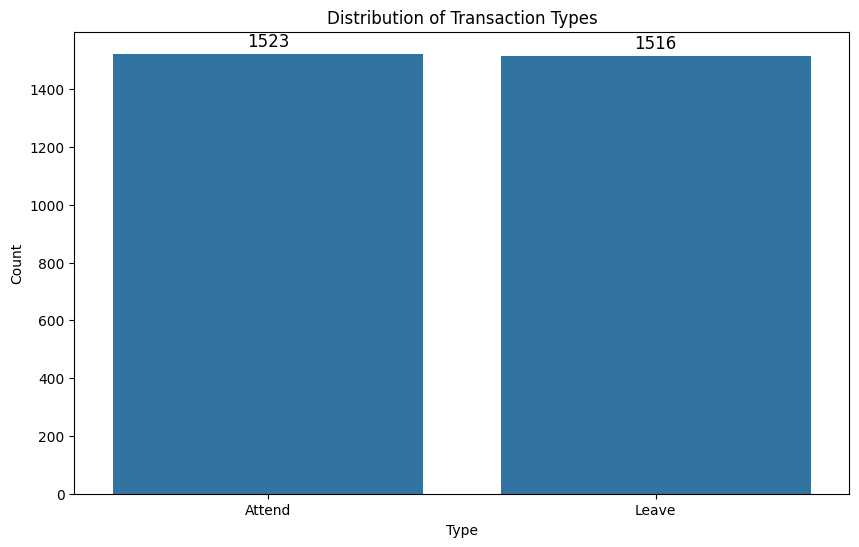

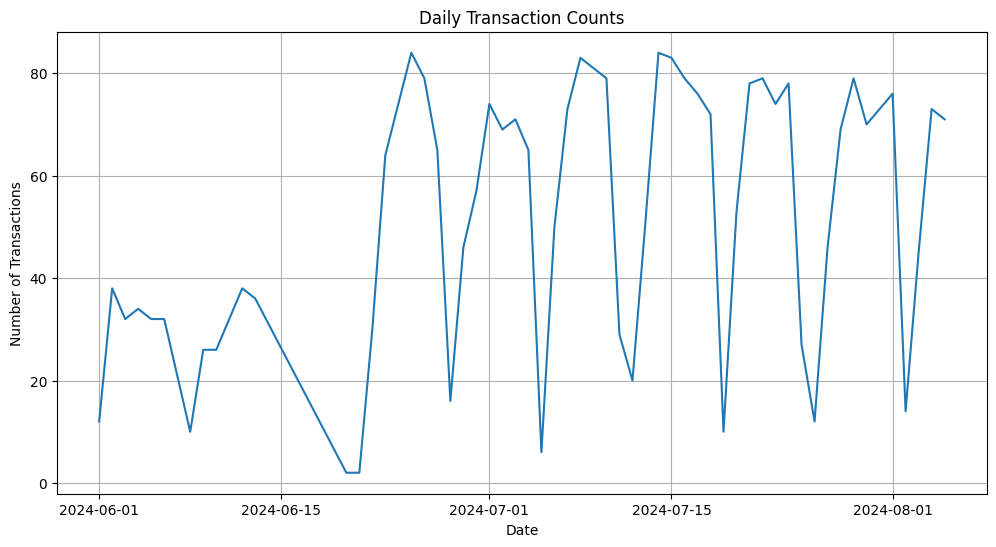

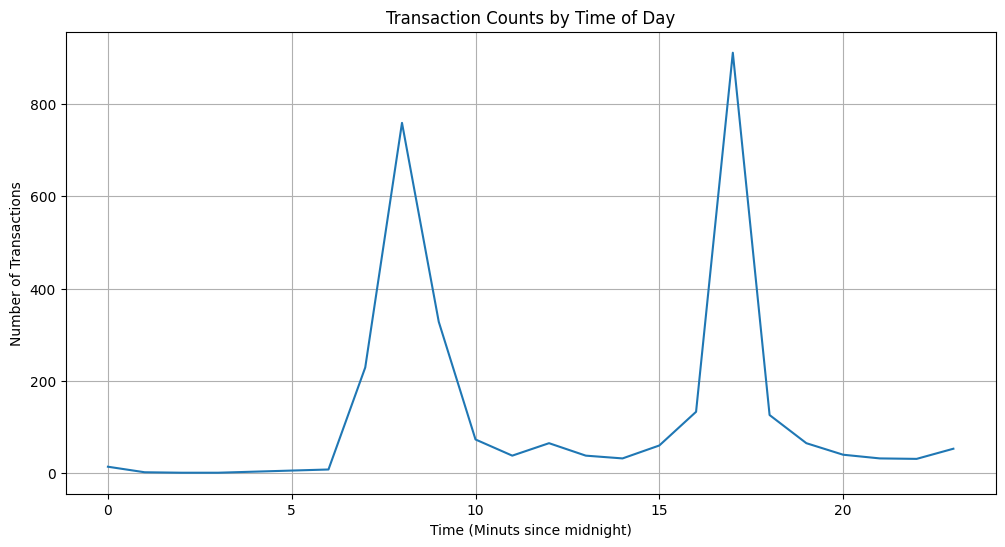

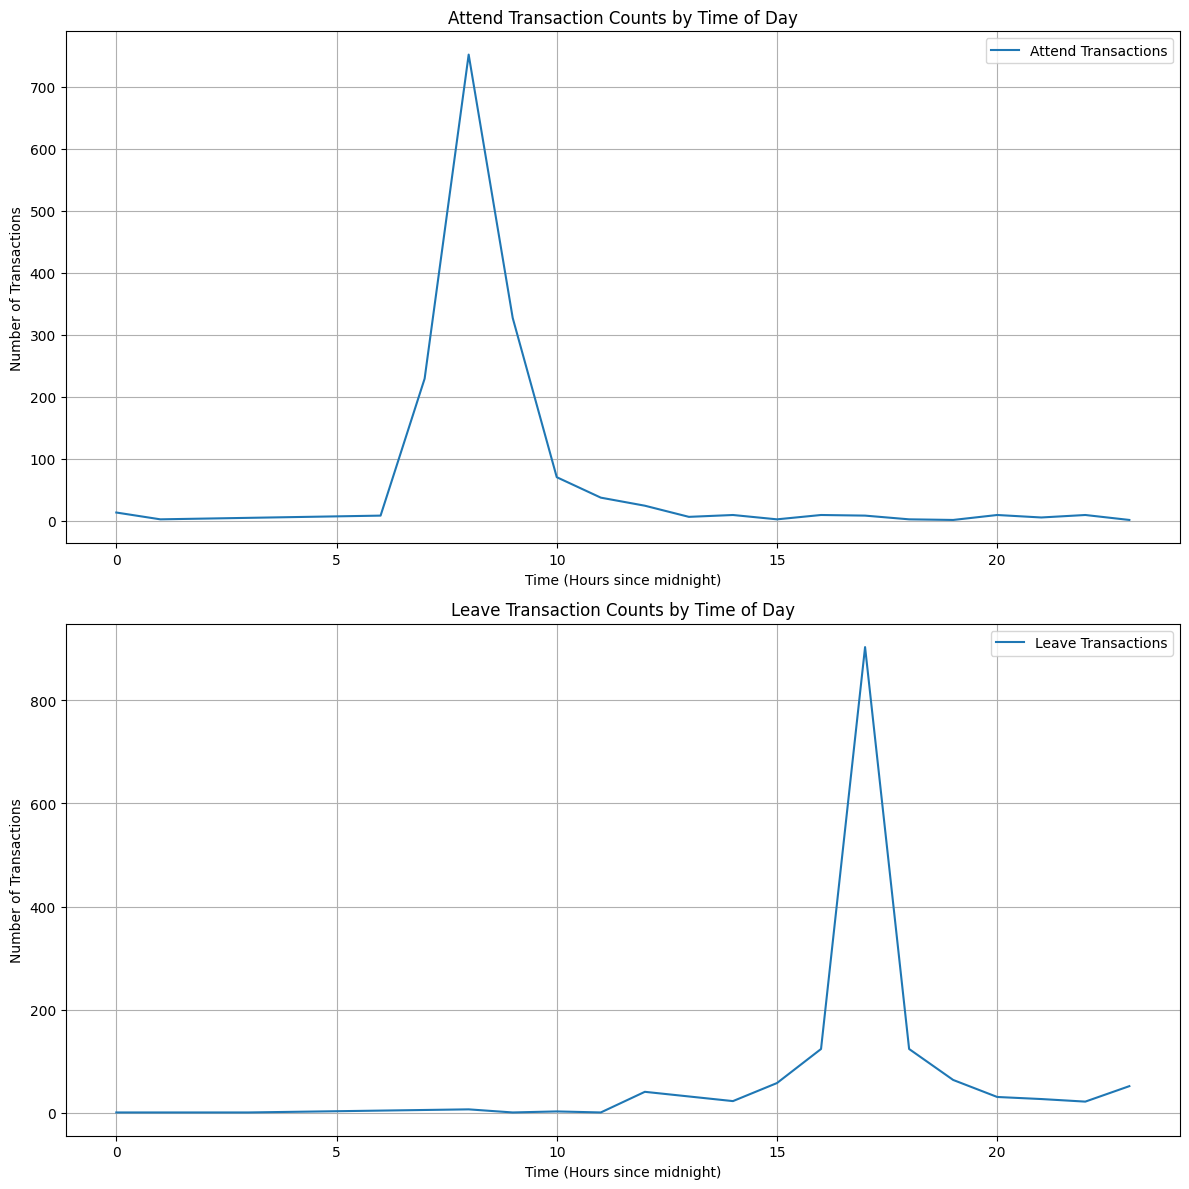

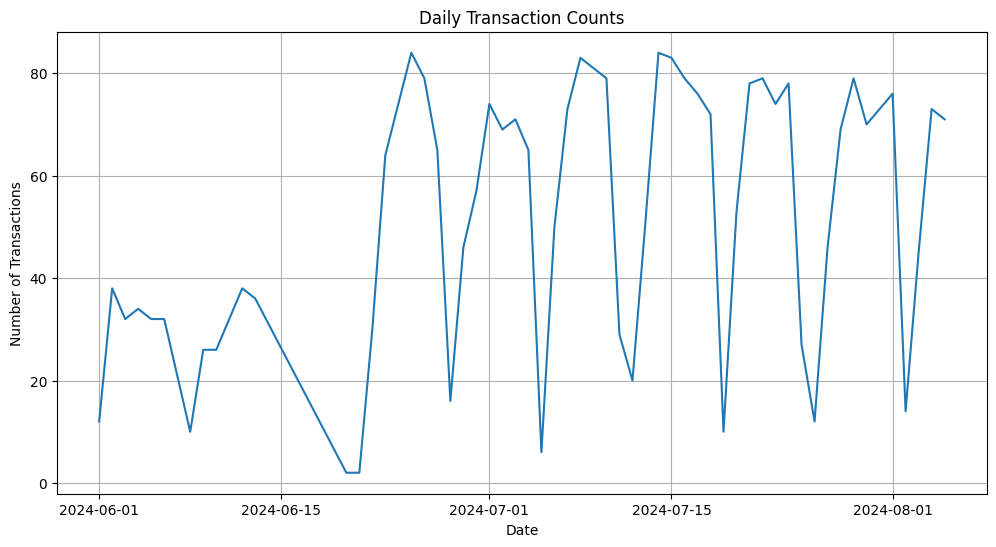

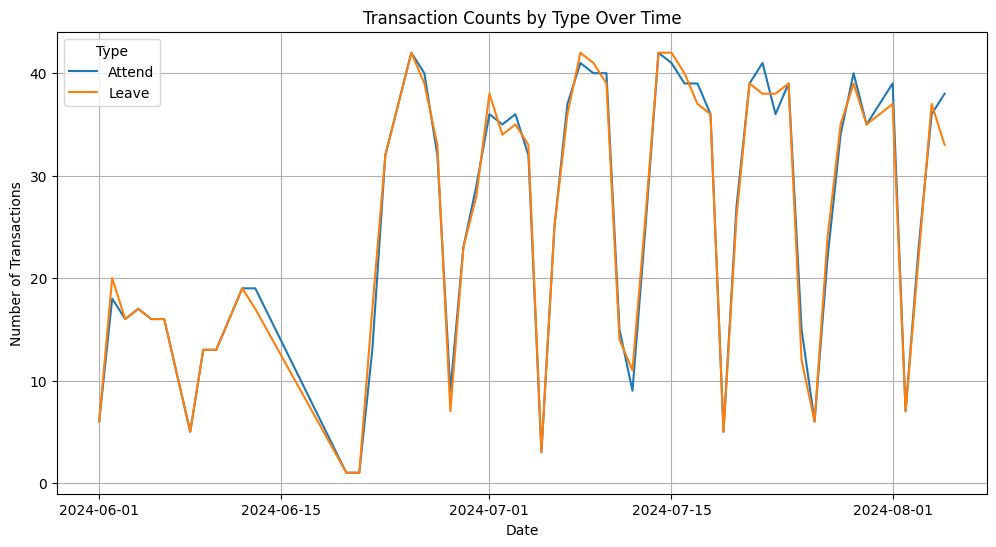

In [13]:

# Distribution of 'Type'
plt.figure(figsize=(10, 6))
sns.countplot(x='Type', data=Dset_filter)
plt.title('Distribution of Transaction Types')
plt.xlabel('Type')
plt.ylabel('Count')

# Annotate the bars with the counts
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()


# Aggregate data by 'TransDate'
daily_counts = Dset_filter.groupby('Transdate').size()

# Plot daily transaction counts
plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title('Daily Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

# Analyze time of day distribution
# Convert 'TransTime' to hours since midnight for easier plotting
def time_to_minutes(t):
    return t.hour #* 60 + t.minute

Dset_filter['TransTimeHours'] = Dset_filter['Transtime'].apply(time_to_minutes)
time_distribution = Dset_filter.groupby('TransTimeHours').size()

# Plot distribution of transactions by time of day
plt.figure(figsize=(12, 6))
plt.plot(time_distribution.index, time_distribution.values)
plt.title('Transaction Counts by Time of Day')
plt.xlabel('Time (Minuts since midnight)')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

def time_to_minutes(t):
    return t.hour  # Simplified to only get hours

# Assuming Dset_filter is your DataFrame and it contains the 'Transtime' column formatted correctly
Dset_filter['Transtime'] = pd.to_datetime(Dset_filter['Transtime'], format='%H:%M:%S')  # Convert time strings to datetime objects if not already
Dset_filter['TransTimeHours'] = Dset_filter['Transtime'].dt.time.apply(time_to_minutes)

# Plotting function to avoid repetition
def plot_transactions(data, transaction_type, ax):
    filtered_data = data[data['Type'] == transaction_type]
    time_distribution = filtered_data.groupby('TransTimeHours').size()
    
    ax.plot(time_distribution.index, time_distribution.values, label=f'{transaction_type} Transactions')
    ax.set_title(f'{transaction_type} Transaction Counts by Time of Day')
    ax.set_xlabel('Time (Hours since midnight)')
    ax.set_ylabel('Number of Transactions')
    ax.grid(True)
    ax.legend()

# Create a figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# Plot Attend Transactions
plot_transactions(Dset_filter, 'Attend', axs[0])

# Plot Leave Transactions
plot_transactions(Dset_filter, 'Leave', axs[1])

plt.tight_layout()
plt.show()

daily_counts = Dset_filter.groupby('Transdate').size()

plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title('Daily Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
# Annotate the bars with the counts
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

# Aggregating by 'Type' and 'TransDate'
type_counts = Dset_filter.groupby(['Transdate', 'Type']).size().unstack().fillna(0)

# Plotting aggregated counts by type
type_counts.plot(figsize=(12, 6))
plt.title('Transaction Counts by Type Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()


In [7]:
# Filter for Type 'Leave' and 'Attend'
filtered_df = Dset_filter[Dset_filter['Type'].isin(['Leave', 'Attend'])]

# Count transactions per day for each EmployeeId and Type
transaction_counts = filtered_df.groupby(['EmployeeId', 'Transdate', 'Type']).size().reset_index(name='TransactionCount')

# Filter to show only where the transaction count > 2
transaction_counts_filtered = transaction_counts[transaction_counts['TransactionCount'] > 2]

# Pivot the table for better readability
pivot_table = transaction_counts_filtered.pivot_table(index=['EmployeeId', 'Transdate'], columns='Type', values='TransactionCount', fill_value=0)

# Display the result
print(pivot_table)

# Save the data to CSV file and Ensure directory exists
#output_dir = '../../data/processed/3340_giza'
#os.makedirs(output_dir, exist_ok=True)
#pivot_table.to_csv(os.path.join(output_dir, 'giza_attend_leave_GThan_2.csv'), index=False)

Type                   Attend  Leave
EmployeeId Transdate                
52539      2024-06-25     3.0    0.0
52559      2024-06-22     0.0    3.0
52565      2024-08-03     3.0    0.0
52574      2024-06-30     0.0    3.0
52575      2024-07-27     0.0    3.0


In [8]:
transaction_counts = filtered_df.groupby(['EmployeeId', 'Transdate', 'Type']).size().reset_index(name='TransactionCount')

# Filter to show only where the transaction count > 2
transaction_counts_filtered = transaction_counts[transaction_counts['TransactionCount'] <= 2]

# Pivot the table for better readability
pivot_table = transaction_counts_filtered.pivot_table(index=['EmployeeId', 'Transdate'], columns='Type', values='TransactionCount', fill_value=0)

# Display the result
print(pivot_table)
#pivot_table.to_csv(os.path.join(output_dir, 'giza_attend_leave_LThan_3.csv'), index=False)

Type                   Attend  Leave
EmployeeId Transdate                
52524      2024-06-02     1.0    2.0
           2024-06-03     1.0    1.0
           2024-06-04     1.0    1.0
           2024-06-05     1.0    1.0
           2024-06-06     1.0    1.0
...                       ...    ...
53152      2024-07-30     1.0    1.0
           2024-07-31     1.0    1.0
           2024-08-01     1.0    1.0
           2024-08-04     1.0    1.0
           2024-08-05     1.0    1.0

[1462 rows x 2 columns]
